In [1]:
import json
import chainlit as cl
from langgraph.graph import StateGraph, END
from typing import TypedDict, Annotated, Sequence, Optional, List, Union
from langchain_core.messages import BaseMessage, SystemMessage, HumanMessage, ToolMessage, AIMessage
from langchain_ollama import ChatOllama
from langchain_core.tools import tool
from langchain.chat_models import init_chat_model
from langchain_neo4j import Neo4jGraph
from dotenv import load_dotenv
import os
import io
import pandas as pd
from io import StringIO
from langgraph.prebuilt import ToolNode
from langchain_tavily import TavilySearch

load_dotenv()

NEO4J_URL = os.getenv("NEO_URL")
NEO4J_USERNAME = os.getenv("NEO4J_USERNAME")
NEO4J_PASSWORD = os.getenv("NEO4J_PASSWORD")
NEO4J_DATABASE = os.getenv("NEO4J_DATABASE")
OPENAI_API_KEY = os.getenv("OPENAI_API_KEY")
graph = Neo4jGraph(url=NEO4J_URL, username=NEO4J_USERNAME, password=NEO4J_PASSWORD, database=NEO4J_DATABASE)

graph.refresh_schema()
SCHEMA_DESCRIPTION = graph.schema

SYSTEM_PROMPT = f"""
You are an expert in generating Cypher queries for Neo4j graph databases based on user questions.

Strict Instructions:
- You MUST respond with only the executable Cypher query — no explanations, comments, or extra text.
- Always wrap labels and relationship in backticks.
- Use **descriptive and meaningful variable names** based on the schema.
- If the user question includes only a partial name (e.g., just first name or just last name), 
  match the name field using `CONTAINS`, `STARTS WITH`, or `ENDS WITH` and instead of 
  strict equality and Perform case-insensitive matching using `toLower()` on both sides in case of lowercase input.

You are provided with the graph schema. Understand the schema in depth. Then:

1. Generate the Cypher query using only valid elements from the schema.
2. Always wrap multi-word labels (e.g., Technician Team, Customer Support Team) and multi-word relationship types (if any) in backticks.
3. If the schema does not support the question, respond with:
   INVALID — [brief explanation]
4. 
   - Do **not** use `DISTINCT` if each occurrence is semantically meaningful (e.g., listing all or total interactions or events).
   - Decide automatically based on schema and query intent whether use `DISTINCT` or not.  
5. After generating the query, reassess the user question and schema to ensure full alignment. If necessary, revise the query accordingly.

Your response must be either:
- A valid Cypher query in correct executable format with no extra word not either cypher keyword
- Or INVALID — followed by a short explanation

Graph Schema:
==============================================================
{SCHEMA_DESCRIPTION}
==============================================================
"""

# print(gpt_llm)


# -------- Tools --------
search_tool = TavilySearch(
    max_results=2,
    topic="general",
)

2025-08-12 16:26:14 - Loaded .env file


In [3]:
import json
import chainlit as cl
from langgraph.graph import StateGraph, END
from typing import TypedDict, Annotated, Sequence, Optional, List, Union
from langchain_core.messages import BaseMessage, SystemMessage, HumanMessage, ToolMessage, AIMessage
from langchain_ollama import ChatOllama
from langchain_core.tools import tool
from langchain.chat_models import init_chat_model
from langchain_neo4j import Neo4jGraph
from dotenv import load_dotenv
import os
import io
import pandas as pd
from io import StringIO
from langgraph.prebuilt import ToolNode
from langchain_tavily import TavilySearch
import re
load_dotenv()

NEO4J_URL = os.getenv("NEO_URL")
NEO4J_USERNAME = os.getenv("NEO4J_USERNAME")
NEO4J_PASSWORD = os.getenv("NEO4J_PASSWORD")
NEO4J_DATABASE = os.getenv("NEO4J_DATABASE")
OPENAI_API_KEY = os.getenv("OPENAI_API_KEY")
graph = Neo4jGraph(url=NEO4J_URL, username=NEO4J_USERNAME, password=NEO4J_PASSWORD, database=NEO4J_DATABASE)

graph.refresh_schema()
SCHEMA_DESCRIPTION = graph.schema

SYSTEM_PROMPT = f"""
You are an expert in generating Cypher queries for Neo4j graph databases based on user questions.

Strict Instructions:
- You MUST respond with only the executable Cypher query — no explanations, comments, or extra text.
- Always wrap labels and relationship in backticks.
- Use **descriptive and meaningful variable names** based on the schema.
- If the user question includes only a partial name (e.g., just first name or just last name), 
  match the name field using `CONTAINS`, `STARTS WITH`, or `ENDS WITH` and instead of 
  strict equality and Perform case-insensitive matching using `toLower()` on both sides in case of lowercase input.

You are provided with the graph schema. Understand the schema in depth. Then:

1. Generate the Cypher query using only valid elements from the schema.
2. Always wrap multi-word labels (e.g., Technician Team, Customer Support Team) and multi-word relationship types (if any) in backticks.
3. If the schema does not support the question, respond with:
   INVALID — [brief explanation]
4. 
   - Do **not** use `DISTINCT` if each occurrence is semantically meaningful (e.g., listing all or total interactions or events).
   - Decide automatically based on schema and query intent whether use `DISTINCT` or not.  
5. After generating the query, reassess the user question and schema to ensure full alignment. If necessary, revise the query accordingly.

Your response must be either:
- A valid Cypher query in correct executable format with no extra word not either cypher keyword
- Or INVALID — followed by a short explanation

Graph Schema:
==============================================================
{SCHEMA_DESCRIPTION}
==============================================================
"""

# print(gpt_llm)


# -------- Tools --------
search_tool = TavilySearch(
    max_results=2,
    topic="general",
)


@tool
def google_search(query: str) -> str:
    """Use Tavily to search the web for the given query."""
    print("\n I m in tavily search")
    global GOOGLE_SEARCH
    GOOGLE_SEARCH = True
    return search_tool.invoke(query)
    
tools = [google_search]
#llm = ChatOllama(model = "qwen2.5", streaming = True).bind_tools(tools)
llm = init_chat_model("openai:gpt-4.1-mini").bind_tools(tools)


class AgentState(TypedDict):
    messages: List[Union[HumanMessage, AIMessage]]
    rewritten_question: Optional[str]
    cypher_query: Optional[str]
    query_result: Optional[str]
    query_error: Optional[str]
    retry_count: int
    final_answer: Optional[str]
    save_to_file: Optional[str]

# Detect file type
def detect_file_type(lower_msg: str) -> Optional[str]:
    file_type = None

    # List of negation patterns
    negations = ["do not", "don't", "not", "no", "never"]

    def is_negated(keyword: str) -> bool:
        # Look for negation within a 5-word window before the keyword
        pattern = rf"({'|'.join(negations)})[\w\s,]{{0,30}}{re.escape(keyword)}"
        return re.search(pattern, lower_msg)

    # Check Excel
    for kw in ["excel file", "xl file", ".xlsx", "spreadsheet"]:
        if kw in lower_msg and not is_negated(kw):
            file_type = "excel"
            break

    # Check CSV
    if file_type is None:
        for kw in ["csv file", ".csv", "comma separated", "csv format"]:
            if kw in lower_msg and not is_negated(kw):
                file_type = "csv"
                break

    # Check Text
    if file_type is None:
        for kw in ["text file", ".txt", "plain text", "txt file", "save as text"]:
            if kw in lower_msg and not is_negated(kw):
                file_type = "text"
                break

    return file_type

#Rewrite user question
def rewrite_user_question(state: AgentState) -> AgentState:
    """This node rewrites the user's question using the schema for better query generation."""

    user_msg = next(
        (msg.content for msg in reversed(state["messages"]) if isinstance(msg, HumanMessage)),
        None
    )

    if not user_msg:
        return {
            **state,
            "query_error": "No user question found.",
            "rewritten_question": None,
            "save_to_file": None
        }

    lower_msg = user_msg.lower()
    file_type = None
    file_type = detect_file_type(lower_msg)
    
    # if any(kw in lower_msg for kw in ["excel file", "xl file", ".xlsx", "spreadsheet"]):
    #     file_type = "excel"
    # elif any(kw in lower_msg for kw in ["csv file", ".csv", "comma separated", "csv format"]):
    #     file_type = "csv"
    
    # elif any(kw in lower_msg for kw in ["text file", ".txt", "plain text", "txt file", "save as text"]):
    #     file_type = "text"
    
    prompt = f"""
    You are a helpful assistant that rewrites user questions to align with the structure of a graph database.

    Your task is:
    - ONLY rewrite the user question in natural language using the schema provided, do not generate a Cypher query.
    - DO NOT include any extra text, explanation, or introduction.

    - If the user's question cannot be answered using the schema, reply with:
    INVALID — [brief explanation]

    User Question:
    ==============================================================
    {user_msg}
    ==============================================================

    Graph Schema:
    ==============================================================
    {SCHEMA_DESCRIPTION}
    ==============================================================

    Your response must be one of the following:
    - A rewritten user question (clear, specific, schema-aligned)
    - Or: INVALID — followed by a short explanation
"""


    response = llm.invoke(prompt)

    rewritten = response.content.strip()

    print("\nRewritten question is:", rewritten,"\n")

    if rewritten.upper().startswith("INVALID"):
        return {
            **state,
            "query_error": rewritten,
            "rewritten_question": None,
            "messages": state["messages"] + [AIMessage(content=rewritten)]
        }

    return {
        **state,
        "rewritten_question": rewritten,
        "messages": state["messages"] + [AIMessage(content=rewritten)],
        "save_to_file": file_type
    }

# Generate cypher
def generate_cypher(state: AgentState) -> AgentState:
    """This node will will generate the cypher query against user's question"""
    user_msg = state["rewritten_question"]
    user_prompt = f"""Question: {user_msg}"""
    
    response = llm.invoke([SystemMessage(content=SYSTEM_PROMPT), HumanMessage(content=user_prompt)])
    #print("Generated cypher: ", response.content)
    # print("\n generate_cypher", state)
    if response.content.strip().upper().startswith("INVALID"):
        return {
            **state,
            "query_error": response.content,
            "messages": state["messages"] + [AIMessage(content=response.content)]
        }

    return {
        **state,
        "cypher_query": response.content,
        "messages": state["messages"] + [AIMessage(content=response.content)]
    }



def is_query_invalid(state: AgentState) -> AgentState:
    """This node check if there is error in query?"""
    query_error = state.get("query_error")
    # print("is_query_invalid", state)
    if query_error:
        return "query_not_found"
    else:
        return "query_found"
    

def should_retry(state: AgentState) -> str:
    # print("should_retry", state)
    if state.get("query_error") or state.get("query_result") in (None, "[]", "[]\n", ""):
        if state.get("retry_count", 0) < 2:
            return "retry"
    return "success"

def should_continue(state: AgentState):
    messages = state['messages']
    last_message = messages[-1]
    if not last_message.tool_calls:
        print("I m in should continue, END")
        return "end"
    else:
        print("I m in should continue, CONTINUE")
        return "continue"
    
#Execute cypher
def execute_cypher(state: AgentState) -> AgentState:
    """This node generates a Cypher query based on user's input."""
    query = state.get("cypher_query")
    # print("\n execute_cypher", state)
    if not query:
        return {
            **state,
            "query_error": "No Cypher query to execute."
        }
        
    try:

        result = graph.query(query)
        #print("result ......", result)
        records = [dict(record) for record in result]
        #print("\nRecords: ", str(records))
        return {
            **state,
            "query_result": str(records),
            "query_error": "",
            #"messages": state["messages"] + [AIMessage(content=f"Query Result: {records}")],
            "retry_count": state.get("retry_count", 0) + 1
        }
        
    except Exception as e:
        print("Exception: ", str(e))
        return {
            **state,
            "query_error": str(e),
            # "messages": state["messages"] + [AIMessage(content=f"Execution Error: {str(e)}")],
            "retry_count": state.get("retry_count", 0) + 1
        }
    

# Streaming function
async def stream_llm_response(messages: list[BaseMessage]) -> AIMessage:
    print("I m in streaming function")
    msg = cl.Message(content="")
    await msg.send()

    content = ""
    async for chunk in llm.astream(messages):
        if chunk.content:
            content += chunk.content
            await msg.stream_token(chunk.content)

    await msg.update()
    return AIMessage(content=content)

# Save_to_excel
def save_to_excel(data: str) -> str:
    """
    Saves LLM-generated data to an Excel file.
    """
    file_name = 'data.xlsx'
    try:
        # Clean up LLM formatting: remove code block wrapper
        data = data.strip()
        if data.startswith("```") and data.endswith("```"):
            data = re.sub(r"^```[a-zA-Z]*\n?", "", data)  # remove ``` or ```json
            data = data.strip("`").strip()

        # Try JSON first
        try:
            records = json.loads(data)
            if isinstance(records, list) and all(isinstance(r, dict) for r in records):
                df = pd.DataFrame(records)
            else:
                raise ValueError("Parsed JSON is not a list of dicts")
        except json.JSONDecodeError:
            # Try Markdown or pipe-separated text
            if "|" in data:
                df = pd.read_csv(io.StringIO(data), sep="|", engine="python", skipinitialspace=True)
                # Clean empty columns like 'Unnamed: 0'
                df = df.loc[:, ~df.columns.str.contains('^Unnamed')]
                df.columns = [col.strip() for col in df.columns]
            else:
                # Handle newline-separated column format
                lines = [line.strip() for line in data.strip().split("\n") if line.strip()]
                if len(lines) < 2:
                    return "❌ Not enough data to form a table."
                header = lines[0]
                rows = lines[1:]
                df = pd.DataFrame(rows, columns=[header])

        # Save to Excel
        df.to_excel(file_name, index=False)
        return f"✅ Data saved to '{file_name}' successfully."
    except Exception as e:
        return f"❌ Excel export failed: {str(e)}"

# Save_to_CSV    
def save_to_csv(data: str) -> str:
    """
    Saves LLM-generated data (CSV, JSON, Markdown table, or single-column newline list) to a CSV file.
    """
    file_name = 'data.csv'
    try:
        # Step 1: Remove triple-backtick wrappers if present
        data = data.strip()
        if data.startswith("```") and data.endswith("```"):
            data = re.sub(r"^```[a-zA-Z]*\n?", "", data)
            data = data.strip("`").strip()

        # Step 2: Try JSON
        try:
            records = json.loads(data)
            if isinstance(records, list) and all(isinstance(r, dict) for r in records):
                df = pd.DataFrame(records)
            else:
                raise ValueError("Parsed JSON is not a list of dicts")

        # Step 3: CSV/Markdown
        except json.JSONDecodeError:
            data = data.replace("\r\n", "\n").replace("\r", "\n")

            if "," in data and "\n" in data:
                df = pd.read_csv(io.StringIO(data), sep=",", engine="python", skipinitialspace=True)

            elif "|" in data:
                df = pd.read_csv(io.StringIO(data), sep="|", engine="python", skipinitialspace=True)
                df = df.loc[:, ~df.columns.str.contains('^Unnamed')]
                df.columns = [col.strip() for col in df.columns]

            # Step 4: Handle newline-separated single-column format
            else:
                lines = [line.strip() for line in data.split("\n") if line.strip()]
                if len(lines) < 2:
                    return "❌ Not enough data to form a CSV table."

                col_name = lines[0]
                rows = lines[1:]
                df = pd.DataFrame(rows, columns=[col_name])

        # Step 5: Save to CSV
        df.to_csv(file_name, index=False)
        return f"✅ Data saved to '{file_name}' successfully."

    except Exception as e:
        return f"❌ CSV export failed: {str(e)}"
    

#Generate final ans
async def generate_final_answer(state: AgentState) -> AgentState:
    """This node converts query result into a natural language answer."""
    user_question = next(
        (msg.content for msg in reversed(state["messages"]) if isinstance(msg, HumanMessage)),
        None)

    query_result = state.get("query_result")
    query_error = state.get("query_error")
    file_type = state.get('save_to_file')
    print("\nWant file: ", file_type)

    if isinstance(query_result, str):
        try:
            parsed_result = json.loads(query_result)
        except json.JSONDecodeError:
            parsed_result = query_result
    else:
        parsed_result = query_result
    
    # Remove duplicate dictionaries
    if isinstance(parsed_result, list) and all(isinstance(x, dict) for x in parsed_result):
        unique_items = []
        seen = set()
        for item in parsed_result:
            frozen = frozenset(item.items())
            if frozen not in seen:
                seen.add(frozen)
                unique_items.append(item)
        parsed_result = unique_items
    
    system_prompt = f"""
    You are Nooora, a helpful and friendly chatbot for 'Home Salon by Nooora', a home salon service provider in Dubai.

    You will be given:
    - A **user question**
    - A **result** fetched from a Neo4j graph database based on that question
    - (Optional) Any **query error** that may have occurred

    Your task:
    - If `parsed_result` has valid data, write a **natural, warm, and informative response** using it.
    - If multiple results are present, format them clearly as bullet points.
    - If `parsed_result` is empty, politely say that no data was found and suggest the user ask something else.
    - If there’s a `query_error`, include a friendly message saying something went wrong with processing the request.
        - If {file_type} is excel, then you must response in excel format.
        - If {file_type} is csv, then you must response in csv format.
    Use the following inputs:

    Question:
    ```
    {user_question}
    ```

    Database Result Summary:
    ```
    {parsed_result}
    ```

    Query Error:
    ```
    {query_error}
    ```

    Excel Format:
    ```
    {file_type}
    ```
    """

    print("\nI m in final ans, before llm\n")
    if state.get("save_to_file"):
        print("\nI m in NOT STREAMING MODE")
        response = llm.invoke([HumanMessage(content=system_prompt)])

        print("\nBefore Saving to File: ", response.content)
        if file_type == "excel":
            excel_function_response = save_to_excel(response.content)
            print("\n",excel_function_response)
        elif file_type == "csv":
            csv_function_response = save_to_csv(response.content)
            print("\n",csv_function_response)
    else:
        response = await stream_llm_response([HumanMessage(content=system_prompt)])


    final_ans = response.content
    print("\nfinal llm response content : ", response.content, "\n")
    
    # Return updated state
    return {
        **state,
        "final_answer": final_ans,
        "messages": state["messages"] + [AIMessage(content=final_ans)]
    }


n_graph = StateGraph(AgentState)
n_graph.add_node("rewrite_user_question", rewrite_user_question)
n_graph.add_node("generate_cypher", generate_cypher)
n_graph.add_node("execute_cypher", execute_cypher)
n_graph.add_node("generate_final_answer", generate_final_answer)

tool_node = ToolNode(tools=tools)
n_graph.add_node("tools", tool_node)

n_graph.set_entry_point("rewrite_user_question")

#rewrite user question
n_graph.add_conditional_edges(
    "rewrite_user_question",
    is_query_invalid,
    {
        "query_not_found": "generate_final_answer",
        "query_found": "generate_cypher"
    }
    
)

#gnerate cypher
n_graph.add_conditional_edges(
    "generate_cypher",
    is_query_invalid,
    {
        "query_not_found": "generate_final_answer",
        "query_found": "execute_cypher"
    }
    
)

#should retry
n_graph.add_conditional_edges(
    "execute_cypher",
    should_retry,
    {
        "retry": "generate_cypher",
        "success": "generate_final_answer",
    }
)

n_graph.add_conditional_edges(
    "generate_final_answer",
    should_continue,
    {
        "continue": "tools",
        "end": END,
    }
)

n_graph.add_edge("generate_final_answer", END)
n_graph.add_edge("tools", END)
langgraph_app = n_graph.compile()

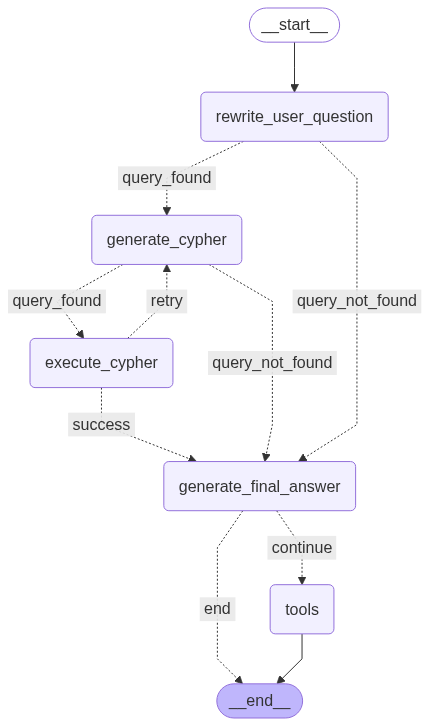

In [4]:
from IPython.display import display, Image
display(Image(langgraph_app.get_graph().draw_mermaid_png()))